# LowResPT — Mask Strategy Visualizer

Set the masking config (the same knobs as `low_res_pt.yaml`) and see what
`mask_patches` actually masks across many sample spectra — analogous to the
recon gallery.

No checkpoint is needed: masking is weight-independent. The notebook runs the
**real** pipeline (`_normalize_flux → _patchify → mask_patches`) so what you see
is exactly what training masks.


In [10]:
import sys, math, collections
import torch, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0, '.')

from model.low_res_pt import LowResPT
from model.masking import mask_patches
from data.datamodule import LowResDataModule

FITS = "/home/yacheng/ssl_outthere/images/DJA/DJA_spectra_v4.5.fits"

dm = LowResDataModule(fits_path=FITS, batch_size=256, num_workers=0,
                      min_sn50=3.0, min_redshift=0.0)
dm.setup()
batch = next(iter(dm.val_dataloader()))
print("batch flux:", tuple(batch["flux"].shape))

sn50 filtering: 10654/24121 samples with sn50 >= 3.0
redshift filtering: 9859/24121 samples with z > 0.0
batch flux: (256, 56)


## Config

Edit `CONFIG` (mirrors the `model:` block of `low_res_pt.yaml`) and re-run the
cells below. `SEED` fixes which tokens are randomly chosen.

In [11]:
# ── Masking config — same knobs as low_res_pt.yaml ──────────────────────────
CONFIG = dict(
    patch_size              = 4,
    stride                  = 2,
    patch_invalid_threshold = 0.25,
    min_std                 = 0.1,
    mask_ratio              = 0.4,
    min_unmasked            = 4,
    max_line_blocks         = 1,
    num_line_detect         = 3,    # detect top-N strongest lines, mask max_line_blocks at random
    continuous_patch_length = 2,    # block length C (1, 2, or 3)
    line_prominence         = 1.2,
)
SEED = 42   # which tokens get randomly masked (None = fresh draw each run)

In [ ]:
@torch.no_grad()
def compute_masking(batch, cfg, seed=None):
    """Run the real normalize -> patchify -> mask_patches pipeline (CPU, no
    weights) and return everything needed to draw the mask."""
    # Weightless model instance, just to reuse _normalize_flux / _patchify with
    # the chosen patch_size / stride / threshold.
    m = LowResPT(patch_size=cfg["patch_size"], stride=cfg["stride"],
                 patch_invalid_threshold=cfg["patch_invalid_threshold"],
                 min_std=cfg["min_std"]).eval()

    flux, wave, vmask, z = (batch["flux"], batch["wavelength"],
                            batch["valid_mask"], batch["redshift"])

    flux_norm, _, _ = m._normalize_flux(flux, vmask, cfg["min_std"])
    patches, wave_token, valid_patches, token_valid_mask, L_used = m._patchify(
        flux_norm, wave, vmask)

    if seed is not None:
        torch.manual_seed(seed)
    _, mask_tok, line_tok = mask_patches(
        patches, flux_norm[:, :L_used], valid_patches, token_valid_mask,
        mask_ratio              = cfg["mask_ratio"],
        min_unmasked            = cfg["min_unmasked"],
        max_line_blocks         = cfg["max_line_blocks"],
        line_prominence         = cfg["line_prominence"],
        patch_size              = cfg["patch_size"],
        stride                  = cfg["stride"],
        continuous_patch_length = cfg["continuous_patch_length"],
        num_line_detect         = cfg["num_line_detect"],
    )
    return dict(flux_norm=flux_norm, wave=wave, vmask=vmask, z=z,
                L_used=L_used, P=cfg["patch_size"], S=cfg["stride"],
                token_valid=token_valid_mask, mask_tok=mask_tok, line_tok=line_tok)

R = compute_masking(batch, CONFIG, SEED)
N = R["mask_tok"].shape[1]
print(f"tokens/spectrum N={N}, P={R['P']}, S={R['S']}, L_used={R['L_used']}")

## Gallery

Grey line = the normalised flux the model sees. Shaded bands = masked tokens
(**blue** = random, **red** = emission-line anchor). A band spans the token's
pixel range `[t*S, t*S+P)`; with `P>S` neighbouring tokens overlap, so adjacent
bands of the same block visually merge into one length-C run.

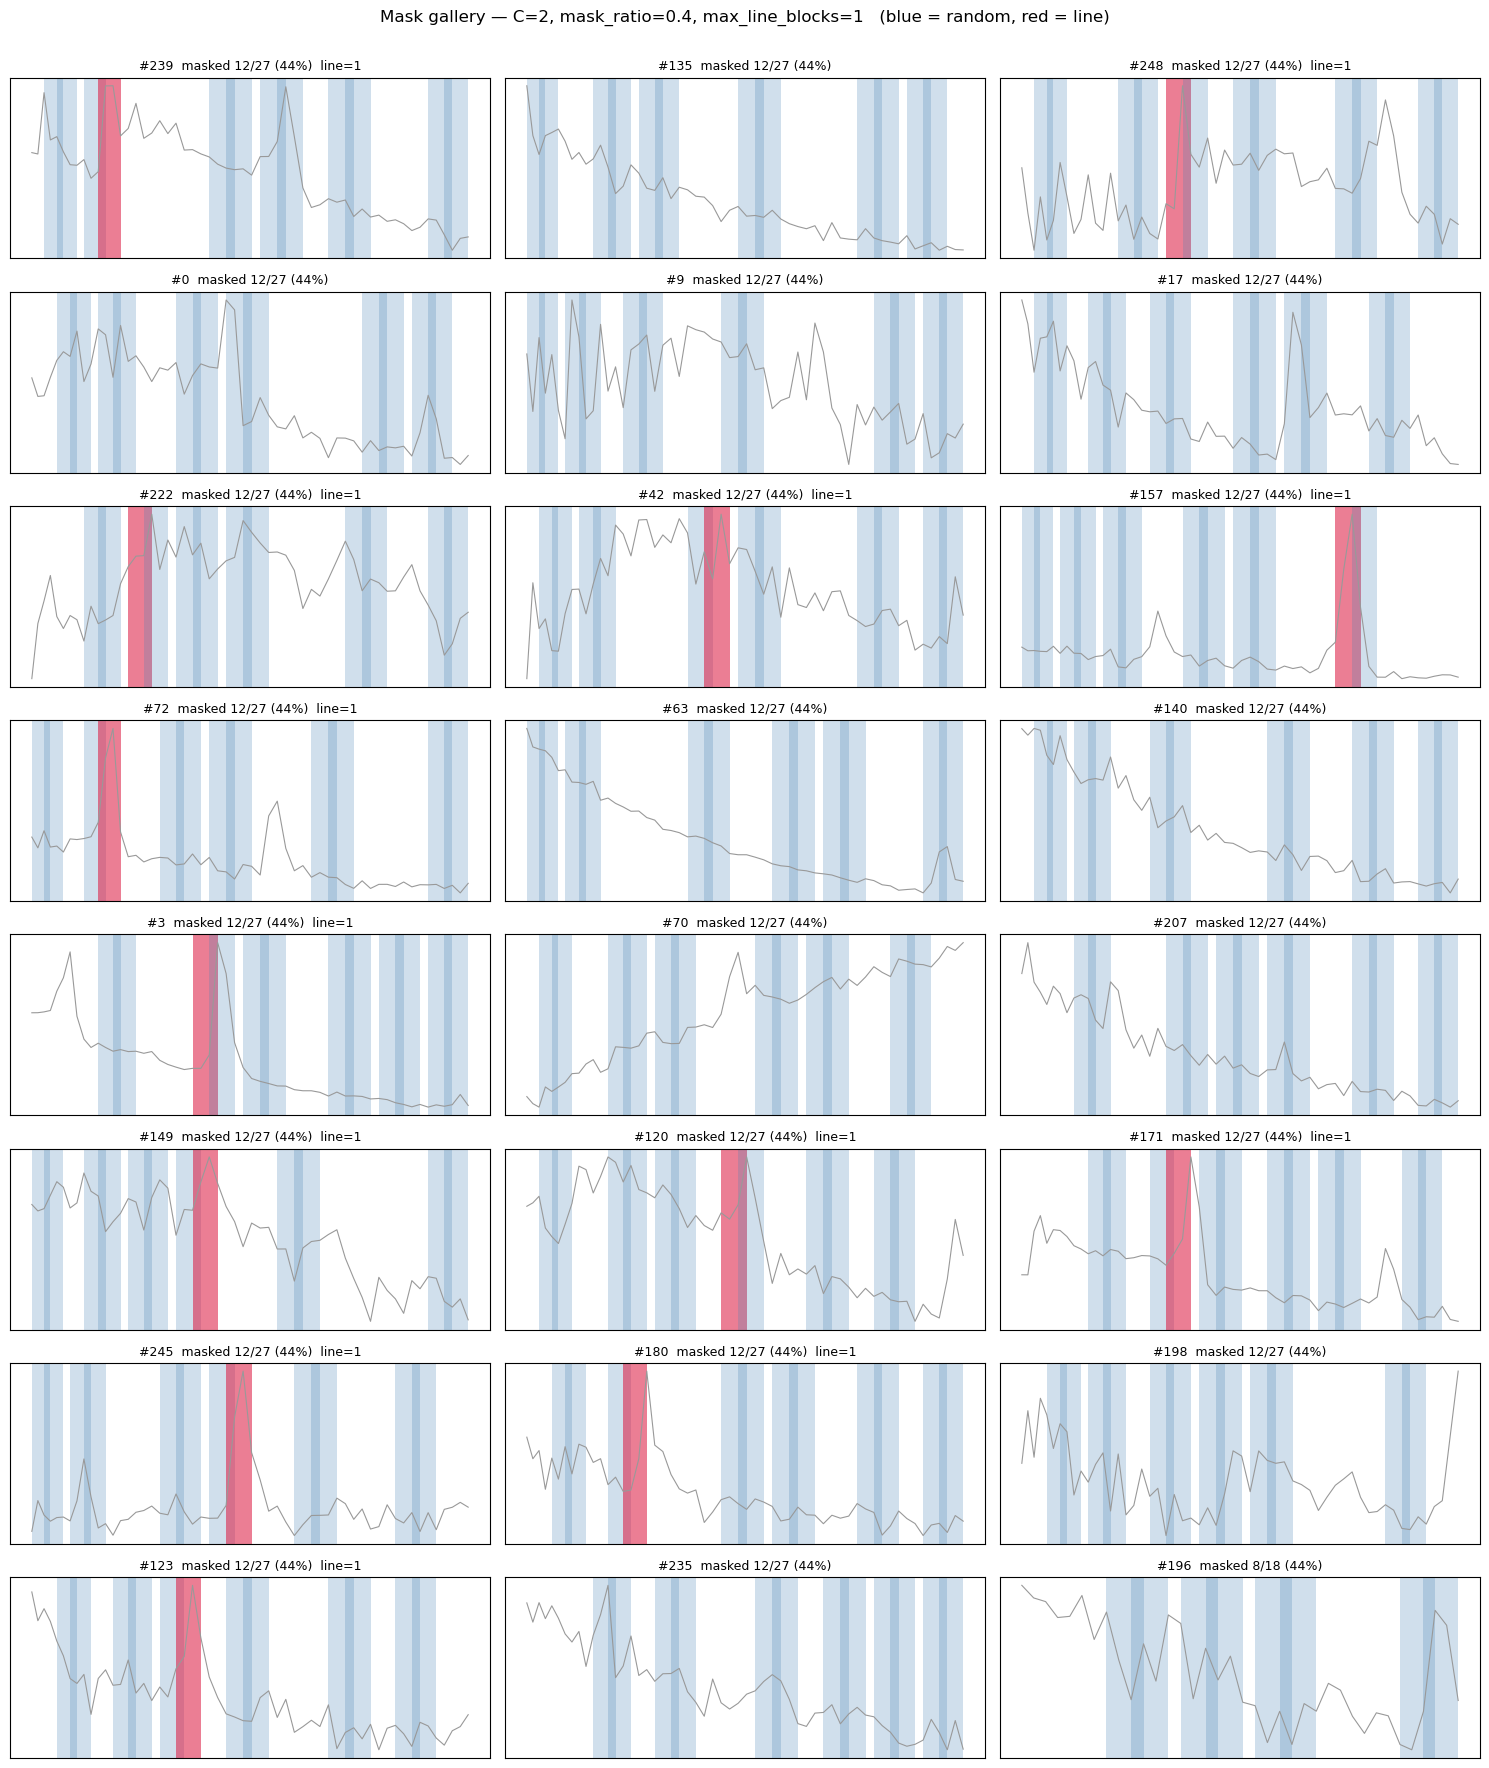

In [13]:
# ── Mask gallery — many samples ─────────────────────────────────────────────
N_GALLERY = 24
MAX_COLS  = 3
PANEL_W, PANEL_H = 5.0, 2.2
SPACE = 'rest'        # 'rest' (divide by 1+z) or 'observed'
GAL_SEED = 0
# ────────────────────────────────────────────────────────────────────────────
P, S, Lu = R["P"], R["S"], R["L_used"]

def token_span(t):
    a = t * S
    b = min(t * S + P, Lu) - 1     # inclusive last pixel
    return a, b

rng   = np.random.default_rng(GAL_SEED)
ntot  = R["flux_norm"].shape[0]
nplot = min(N_GALLERY, ntot)
idxs  = rng.choice(ntot, nplot, replace=False)
nrows = math.ceil(nplot / MAX_COLS)

fig, axes = plt.subplots(nrows, MAX_COLS,
                         figsize=(PANEL_W * MAX_COLS, PANEL_H * nrows),
                         squeeze=False)
flat = axes.flatten()
for ai, idx in enumerate(idxs):
    ax = flat[ai]
    vm = R["vmask"][idx, :Lu].bool().numpy()
    w  = R["wave"][idx, :Lu].numpy().copy()
    if SPACE == 'rest':
        w = w / (1.0 + R["z"][idx].item())
    f  = R["flux_norm"][idx, :Lu].numpy()
    ax.plot(w[vm], f[vm], color="0.6", lw=0.8, zorder=2)

    mtok = R["mask_tok"][idx].nonzero().flatten().tolist()
    ltok = set(R["line_tok"][idx].nonzero().flatten().tolist())
    nval = int(R["token_valid"][idx].sum())
    for t in mtok:
        a, b = token_span(t)
        lo, hi = sorted((w[a], w[b]))
        is_line = t in ltok
        ax.axvspan(lo, hi, color="crimson" if is_line else "steelblue",
                   alpha=0.55 if is_line else 0.25, lw=0, zorder=1)
    frac = len(mtok) / max(nval, 1)
    ttl = f"#{idx}  masked {len(mtok)}/{nval} ({frac:.0%})"
    if ltok:
        ttl += f"  line={len(ltok)}"
    ax.set_title(ttl, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
for ai in range(nplot, len(flat)):
    flat[ai].set_visible(False)
fig.suptitle(f"Mask gallery — C={CONFIG['continuous_patch_length']}, "
             f"mask_ratio={CONFIG['mask_ratio']}, "
             f"max_line_blocks={CONFIG['max_line_blocks']}   "
             f"(blue = random, red = line)", y=1.002)
plt.tight_layout()

## Statistics over the whole val set

Sanity-checks the config: actual masked fraction vs target, contiguous run
lengths (should all equal `C`), and how many emission-line blocks land per
spectrum.

masked fraction : mean=0.444  (target 0.4)  min=0.400  max=0.500
run lengths     : {2: 5893}  (expect all = C=2)
line blocks/spec: mean=0.44  max=1  (<= max_line_blocks=1)


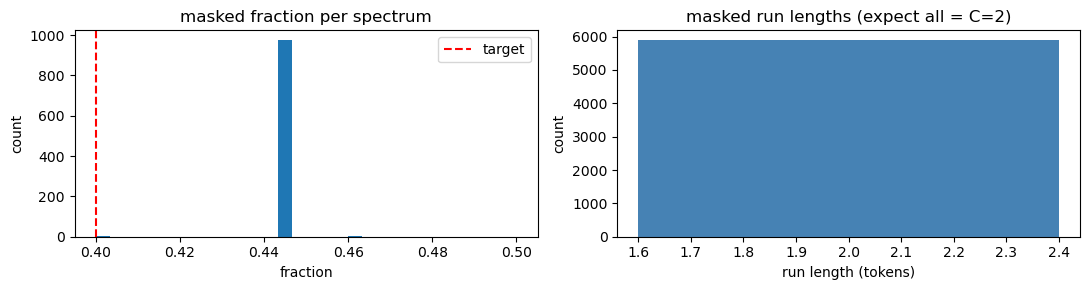

In [14]:
fracs, run_lengths, n_line = [], [], []
torch.manual_seed(SEED if SEED is not None else 0)
for b in dm.val_dataloader():
    Rb = compute_masking(b, CONFIG, seed=None)   # keep one continuous RNG stream
    mt, lt, tv = Rb["mask_tok"], Rb["line_tok"], Rb["token_valid"]
    for i in range(mt.shape[0]):
        idx  = sorted(mt[i].nonzero().flatten().tolist())
        nval = int(tv[i].sum())
        if nval == 0:
            continue
        fracs.append(len(idx) / nval)
        n_line.append(int(lt[i].sum()))
        run = []
        for t in idx:
            if run and t == run[-1] + 1:
                run.append(t)
            else:
                if run:
                    run_lengths.append(len(run))
                run = [t]
        if run:
            run_lengths.append(len(run))

fracs = np.array(fracs)
print(f"masked fraction : mean={fracs.mean():.3f}  (target {CONFIG['mask_ratio']})  "
      f"min={fracs.min():.3f}  max={fracs.max():.3f}")
print(f"run lengths     : {dict(sorted(collections.Counter(run_lengths).items()))}  "
      f"(expect all = C={CONFIG['continuous_patch_length']})")
print(f"line blocks/spec: mean={np.mean(n_line):.2f}  max={max(n_line)}  "
      f"(<= max_line_blocks={CONFIG['max_line_blocks']})")

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].hist(fracs, bins=30, edgecolor="none")
ax[0].axvline(CONFIG["mask_ratio"], color="r", ls="--", label="target")
ax[0].set(title="masked fraction per spectrum", xlabel="fraction", ylabel="count")
ax[0].legend()
bl = collections.Counter(run_lengths)
ax[1].bar(list(bl.keys()), list(bl.values()), color="steelblue")
ax[1].set(title=f"masked run lengths (expect all = C={CONFIG['continuous_patch_length']})",
          xlabel="run length (tokens)", ylabel="count")
plt.tight_layout()